# Farmland — a quantitative teardown 🔬
### CAPM beta of the listed proxies (HAC t) · the inflation regression vs CPI · Geltner appraisal un-smoothing · a closed-form synthetic smoothing control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Smooth %26 uncorrelated%3F: Busted](https://img.shields.io/badge/Smooth_%26_uncorrelated%3F-Busted-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate three claims the folklore fuses: a **real** real-asset return (genuine), a **weak/unproven** inflation-hedge loading, and a **busted** "low-vol, uncorrelated" property that is an *appraisal-smoothing artifact*. The decisive objects: the CAPM beta of the tradable REITs, the CPI loading of the index, and the un-smoothing identity that restores the hidden volatility and beta.

> ⚠️ **Not investment advice.** Real data: yfinance auto-adjusted month-end LAND/FPI/SPY (2014-02 → 2026-06). The NCREIF farmland / CPI / S&P annual series is a **hardcoded cited public** dataset (1992-2023) — a transparent proxy for the paywalled quarterly index, labelled as such. Synthetic control is deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from farmland import data, strategy as st

HAVE_REAL = data.have_real()
REAL = data.load_real() if HAVE_REAL else None
ANN = data.ncreif_annual()   # hardcoded cited public series — always present
print("listed-proxy price cache present:", HAVE_REAL,
      "| NCREIF annual rows:", len(ANN))

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2014-02 → 2026-06', 'n_land': 149, 'n_fpi': 146, 'land_ret': 4.9, 'land_vol': 30.0, 'land_beta': 0.91, 'land_tbeta': 5.19, 'land_corr': 0.44, 'land_alpha': -8.2, 'land_talpha': -1.03, 'land_sh_g': 0.16, 'land_sh_n': 0.16, 'fpi_ret': 5.5, 'fpi_vol': 29.3, 'fpi_beta': 0.69, 'fpi_tbeta': 4.11, 'fpi_corr': 0.35, 'fpi_alpha': -4.3, 'fpi_talpha': -0.59, 'fpi_sh_g': 0.19, 'fpi_sh_n': 0.18, 'spy_ret': 14.4, 'spy_vol': 14.6, 'spy_sh': 0.98, 'nc_years': '1992-2023', 'nc_n': 32, 'nc_mean': 11.0, 'nc_vol': 6.6, 'nc_rho1': 0.63, 'nc_real': 8.4, 'nc_inflb': 0.66, 'nc_infl_t': 0.83, 'nc_corr_cpi': 0.14, 'nc_corr_spx': -0.13, 'spx_mean': 11.6, 'spx_vol': 17.7, 'spx_inflb': -3.98, 'spx_infl_t': -2.69, 'spx_corr_cpi': -0.33, 'unsm_vol': 13.5, 'vol_ratio': 0.49, 'syn': [(0.1, 0.053, 0.9, 0.32, 0.03), (0.2, 0.111, 0.8, 0.32, 0.06), (0.4, 0.25, 0.6, 0.32, 0.13)]}


listed-proxy price cache present: True | NCREIF annual rows: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | NCREIF inflation-beta **+0.66** but **t = 0.83** (n=32) — positive, *insignificant*; real return +8.4%/yr; tradable proxies are equity-like (β = 0.91, t = 5.2). Real-economy plausible, not a robust t≥2 tradable signal. |
| **Tradability** | `FRAGILE` | LAND/FPI net Sharpe **0.16/0.18** vs SPY **0.98**, ann vol **~30%**; small, leveraged, illiquid REITs. Buyable, poor risk-adjusted, not the smooth index. |
| **Smooth & uncorrelated?** | `BUSTED` | Appraisal ρ₁ = **0.63**; un-smoothing lifts vol 6.6% → **13.5%**. Synthetic control: a true 0.32 beta is reported as 0.03–0.13 — the "uncorrelated" calm is mechanical. |

> 💡 In plain words: farmland really earns a real return, but its reputation as a calm, uncorrelated inflation shield is an accounting illusion — and the only thing you can hold is a jumpy, leveraged REIT.

## 1 · The claim, steelmanned

Let $r^{F}_t$ be farmland's total return, $\pi_t$ realised CPI inflation, $r^{M}_t$ the market return. The pitch is three hypotheses:

- **H₁ (real inflation hedge).** In $r^{F}_t = \alpha + \beta_\pi \pi_t + \varepsilon_t$, $\beta_\pi > 0$ and significant.
- **H₂ (low-beta diversifier).** In the CAPM $r^{F}_t - r^f = \alpha + \beta_M (r^M_t - r^f) + u_t$, $\beta_M \approx 0$ on the *tradable* asset.
- **H₃ (the smooth index is the true risk).** The reported volatility and $\beta_M$ are the volatility and beta you actually bear.

We find **H₁ weakly accepted** (sign right, $t = 0.83$), **H₂ rejected** on the tradable proxies ($\beta_M = 0.69$–$0.91$, large $t$), and **H₃ rejected**: the smooth index is an appraisal moving-average whose volatility and beta are shrunk by a known factor.

## 2 · So what? — what rides on each answer

An appraisal-based index reports $r^{app}_t = a\,r^{true}_t + (1-a)\,r^{app}_{t-1}$ (surveyors anchor on last period). For iid true returns this MA(∞) implies, in the limit,

$$\frac{\mathrm{Var}(r^{app})}{\mathrm{Var}(r^{true})} = \frac{a}{2-a},\qquad \rho_1(r^{app}) = 1-a,\qquad \beta^{app}_M \approx a\,\beta^{true}_M.$$

So a small smoothing parameter $a$ **manufactures** low volatility, high autocorrelation, and a near-zero beta — *exactly* the three properties the pitch celebrates. The diagnostics ($\rho_1$) reveal $a$, and the un-smoothing inverts the filter. The signal you can actually trade lives in the listed REITs, where no appraiser intervenes.

## 3 · How we'd know — the protocol

- **Listed proxies.** yfinance auto-adjusted month-end closes, LAND (149 mo), FPI (146 mo), SPY; monthly simple total returns. CAPM beta via OLS with **Newey-West HAC** (6 lags) — robust to the autocorrelation overlapping/illiquid returns inject.
- **Inflation regression.** NCREIF farmland annual TR on CPI (1992-2023, n=32), HAC (2 lags); the S&P run as a contrast. The Signal axis is the *sign and significance* of $\beta_\pi$.
- **Un-smoothing.** Geltner first-order reversal $r^{true}_t = (r^{app}_t - \rho\,r^{app}_{t-1})/(1-\rho)$ with $\rho=\hat\rho_1$; report the volatility lift.
- **Positive control.** A deterministic smoothing generator with known $a,\beta$: the measured variance ratio, $\rho_1$ and appraised beta must hit the closed forms $a/(2-a)$, $1-a$, $a\beta$.
- **Costs (named).** One-way 15 bps on NAV for the thin REITs; leverage and illiquidity flagged as caveats, not modelled as alpha. Survivorship: only the two surviving REITs are in the proxy sample.

## 4 · The teardown

### 4a · The tradable proxies are high-beta, not diversifiers

CAPM beta of LAND and FPI on SPY, with HAC standard errors. A real low-beta diversifier would sit near zero; these don't.

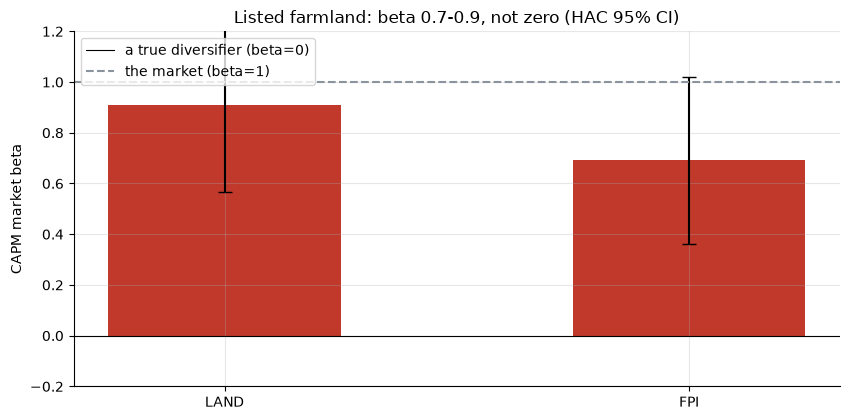

LAND: beta=0.91  HAC t=5.19
FPI: beta=0.69  HAC t=4.11


In [2]:
if HAVE_REAL:
    rets = REAL['returns']
    res = {c: st.market_beta(rets[c], rets['SPY'], lags=6) for c in ['LAND','FPI']}
    betas = [res['LAND']['beta'], res['FPI']['beta']]
    ses   = [res['LAND']['se_beta'], res['FPI']['se_beta']]
    ts    = [res['LAND']['t_beta'], res['FPI']['t_beta']]
else:
    betas = [R['land_beta'], R['fpi_beta']]
    ts    = [R['land_tbeta'], R['fpi_tbeta']]
    ses   = [b/t for b,t in zip(betas, ts)]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['LAND','FPI'], betas, yerr=[1.96*s for s in ses], capsize=5, color=RED, width=.5)
ax.axhline(0, c='k', lw=.8, label='a true diversifier (beta=0)')
ax.axhline(1, ls='--', c=GREY, label='the market (beta=1)')
ax.set_ylabel('CAPM market beta'); ax.set_ylim(-.2, 1.2)
ax.set_title('Listed farmland: beta 0.7-0.9, not zero (HAC 95% CI)'); ax.legend()
plt.tight_layout(); plt.show()
for c,b,t in zip(['LAND','FPI'], betas, ts): print(f'{c}: beta={b:.2f}  HAC t={t:.2f}')

> 💡 In plain words: LAND's beta is **0.91** (HAC t = 5.2), FPI's **0.69** (t = 4.1) — both decisively *not* zero. The only farmland you can hold trades like a high-vol equity. **H₂ rejected** on the tape.

### 4b · The inflation hedge is real-but-weak

NCREIF farmland annual return regressed on CPI (the empirical content of "inflation hedge"), with the S&P 500 as a contrast. Positive slope = hedges; significance = whether we can trust it.

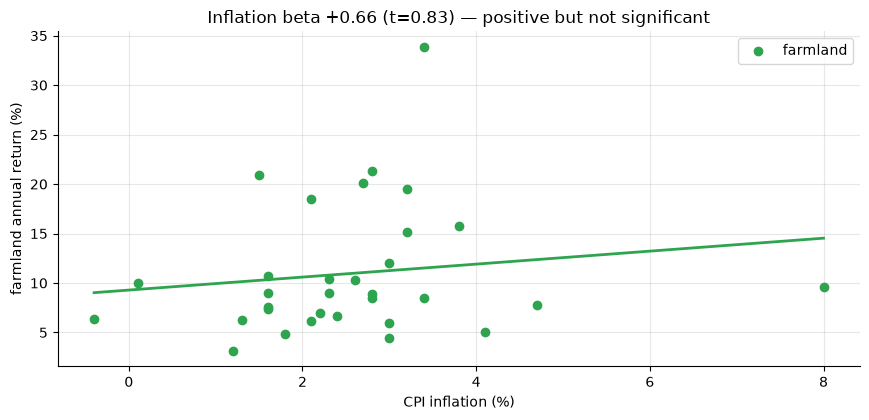

farmland: infl-beta=+0.66 (t=0.83)  corr_CPI=+0.14  mean real=8.4%
S&P 500 : infl-beta=-3.98 (t=-2.69)  corr_CPI=-0.33


In [3]:
rf = st.inflation_beta(ANN, 'farmland', lags=2)
rs = st.inflation_beta(ANN, 'spx', lags=2)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
x = ANN['cpi'].values*100
ax.scatter(x, ANN['farmland'].values*100, c=GREEN, label='farmland', zorder=3)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (rf['alpha'] + rf['beta']*xs/100)*100, c=GREEN, lw=2)
ax.set_xlabel('CPI inflation (%)'); ax.set_ylabel('farmland annual return (%)')
ax.set_title(f"Inflation beta +{rf['beta']:.2f} (t={rf['t_beta']:.2f}) — positive but not significant")
ax.legend(); plt.tight_layout(); plt.show()
print(f"farmland: infl-beta={rf['beta']:+.2f} (t={rf['t_beta']:.2f})  corr_CPI={rf['corr_cpi']:+.2f}  mean real={rf['mean_real']*100:.1f}%")
print(f"S&P 500 : infl-beta={rs['beta']:+.2f} (t={rs['t_beta']:.2f})  corr_CPI={rs['corr_cpi']:+.2f}")

> 💡 In plain words: farmland's inflation loading is **+0.66** but **t = 0.83** — the right sign, not significant on 32 years. Equities load *negatively* (−4.0, t = -2.7), so farmland is the better inflation companion — but "best inflation hedge" overstates what the data can prove. **H₁ weakly accepted → Signal WEAK** (no robust t≥2).

### 4c · The smoothness is an appraisal artifact — un-smoothing

The reported ρ₁ reveals the smoothing; reversing the filter restores the volatility a transaction-based index would show.

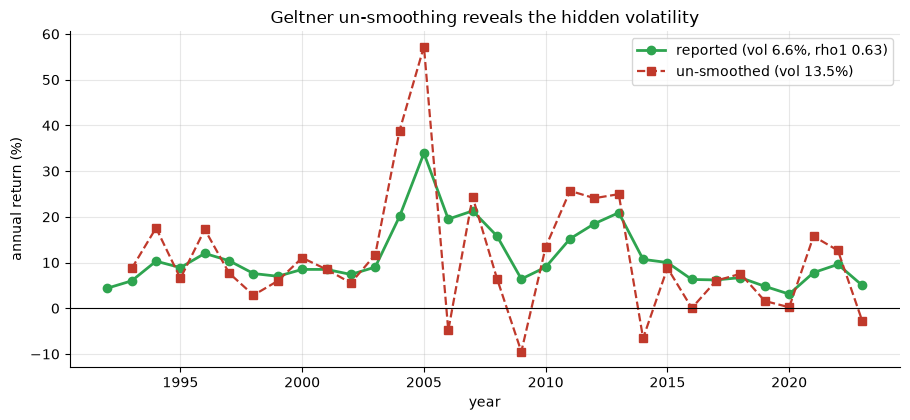

rho1=0.63  reported vol=6.6%  un-smoothed=13.5%  ratio=0.49


In [4]:
rep = ANN['farmland'].values
sm = st.smoothing_summary(rep)
un = st.unsmooth(rep)
yrs = ANN.index.values
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(yrs, rep*100, 'o-', c=GREEN, lw=2, label=f"reported (vol {sm['vol_reported']*100:.1f}%, rho1 {sm['rho1']:.2f})")
ax.plot(yrs[1:], un*100, 's--', c=RED, lw=1.6, label=f"un-smoothed (vol {sm['vol_unsmoothed']*100:.1f}%)")
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annual return (%)'); ax.set_xlabel('year')
ax.set_title('Geltner un-smoothing reveals the hidden volatility'); ax.legend()
plt.tight_layout(); plt.show()
print(f"rho1={sm['rho1']:.2f}  reported vol={sm['vol_reported']*100:.1f}%  un-smoothed={sm['vol_unsmoothed']*100:.1f}%  ratio={sm['vol_ratio']:.2f}")

> 💡 In plain words: ρ₁ = **0.63** is far too high for a freely-traded asset — it's the appraisal moving-average. Inverting it lifts volatility 6.6% → **13.5%** (the survey hides ~51%). **H₃ rejected.**

### 4d · Faithful-engine control — measured shrink = closed form

On a deterministic smoothed tape with known $a$ and a true beta of 0.30, the measured variance ratio, ρ₁ and appraised beta must equal $a/(2-a)$, $1-a$, $\approx a\beta$:

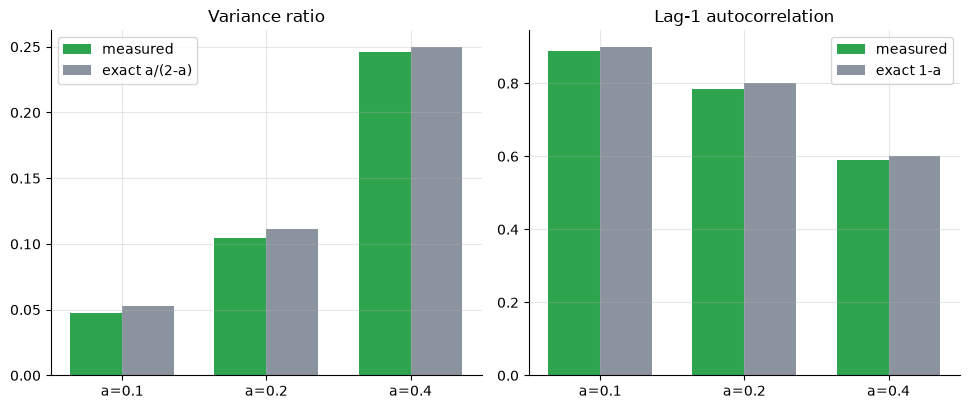

a=0.1: var-ratio 0.048 (exact 0.053)  rho1 0.888 (exact 0.900)  true beta 0.30 -> appraised 0.03
a=0.2: var-ratio 0.105 (exact 0.111)  rho1 0.786 (exact 0.800)  true beta 0.30 -> appraised 0.06
a=0.4: var-ratio 0.246 (exact 0.250)  rho1 0.591 (exact 0.600)  true beta 0.30 -> appraised 0.13


In [5]:
rows = []
for a in (0.10, 0.20, 0.40):
    df = data.synthetic_smoothing(n=4000, a=a, beta=0.30, seed=359)
    vr = np.var(df['app'],ddof=1)/np.var(df['true'],ddof=1)
    rho = st.autocorr(df['app'].values,1)
    ba = st.ols_hac(df['app'].values, df['mkt'].values, lags=4)['beta']
    rows.append((a, vr, st.expected_var_ratio(a), rho, st.expected_rho1(a), ba))
a_=[r[0] for r in rows]; x=np.arange(len(a_))
fig, (p1,p2) = plt.subplots(1,2,figsize=(9.8,4.2))
p1.bar(x-.18,[r[1] for r in rows],.36,color=GREEN,label='measured')
p1.bar(x+.18,[r[2] for r in rows],.36,color=GREY,label='exact a/(2-a)')
p1.set_xticks(x); p1.set_xticklabels([f'a={a}' for a in a_]); p1.set_title('Variance ratio'); p1.legend()
p2.bar(x-.18,[r[3] for r in rows],.36,color=GREEN,label='measured')
p2.bar(x+.18,[r[4] for r in rows],.36,color=GREY,label='exact 1-a')
p2.set_xticks(x); p2.set_xticklabels([f'a={a}' for a in a_]); p2.set_title('Lag-1 autocorrelation'); p2.legend()
plt.tight_layout(); plt.show()
for a,vr,vre,rho,rhoe,ba in rows: print(f'a={a}: var-ratio {vr:.3f} (exact {vre:.3f})  rho1 {rho:.3f} (exact {rhoe:.3f})  true beta 0.30 -> appraised {ba:.2f}')

> 💡 In plain words: the engine reproduces the closed-form shrink at every $a$ — the "low volatility, near-zero beta" of an appraisal index is a *mechanical* consequence of smoothing, not a property of farmland. A true 0.30 beta is reported as 0.03–0.13.

## 5 · The verdict

- **Signal `WEAK`** — inflation-beta +0.66 (t = 0.83, n = 32): right sign, *not significant*; real return +8.4%/yr is genuine, but the tradable proxies are equity-like (β = 0.7–0.9, large t). Real-economy plausible, no robust t≥2 tradable signal.
- **Tradability `FRAGILE`** — LAND/FPI net Sharpe 0.16/0.18 vs SPY 0.98, ~30% vol; small, leveraged, illiquid. Buyable, poor, and nothing like the smooth index.
- **Smooth & uncorrelated? `BUSTED`** — ρ₁ = 0.63; un-smoothing lifts vol 6.6% → 13.5%; the control shows a true 0.30 beta reported as ~0.05. The calm is measurement, not the asset.

## 6 · Could you trade it? — the risk-adjusted reality

Net-of-cost Sharpe and volatility of the holdable proxies vs the market — the honest risk-adjusted comparison for a real-money allocation.

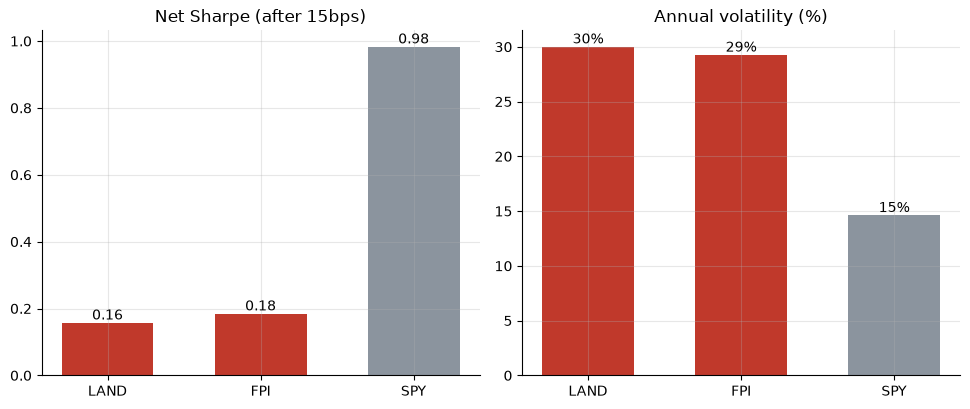

net Sharpe: {'LAND': 0.16, 'FPI': 0.18, 'SPY': 0.98}  vol%: {'LAND': 30.0, 'FPI': 29.0, 'SPY': 15.0}


In [6]:
if HAVE_REAL:
    rets = REAL['returns']
    rows = {c: st.net_sharpe(rets[c], cost_oneway=0.0015) for c in ['LAND','FPI']}
    rows['SPY'] = st.net_sharpe(rets['SPY'], cost_oneway=0.0001)
    sh = {c: rows[c]['sharpe_net'] for c in ['LAND','FPI','SPY']}
    vol = {c: rows[c]['ann_vol']*100 for c in ['LAND','FPI','SPY']}
else:
    sh = {'LAND': R['land_sh_n'], 'FPI': R['fpi_sh_n'], 'SPY': R['spy_sh']}
    vol = {'LAND': R['land_vol'], 'FPI': R['fpi_vol'], 'SPY': R['spy_vol']}
fig, (a1,a2) = plt.subplots(1,2,figsize=(9.8,4.2))
ks = list(sh); cols=[RED,RED,GREY]
a1.bar(ks,[sh[k] for k in ks],color=cols,width=.6); a1.set_title('Net Sharpe (after 15bps)')
for i,k in enumerate(ks): a1.annotate(f'{sh[k]:.2f}',(i,sh[k]),ha='center',va='bottom')
a2.bar(ks,[vol[k] for k in ks],color=cols,width=.6); a2.set_title('Annual volatility (%)')
for i,k in enumerate(ks): a2.annotate(f'{vol[k]:.0f}%',(i,vol[k]),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('net Sharpe:', {k: round(sh[k],2) for k in ks}, ' vol%:', {k: round(vol[k],0) for k in ks})

> 💡 In plain words: net Sharpe ~0.16 on the farmland REITs against ~0.98 on the S&P, at double the volatility. There is no sizing that turns the tradable vehicle into the smooth index — the appraisal calm simply isn't for sale. A small diversifying sleeve is defensible; "the best inflation hedge" is not what the tape shows.

## 7 · Going further

- **Generalised un-smoothing.** Replace the first-order reversal with the Fisher-Geltner multi-lag filter or the Getmansky-Lo-Makarov MA(q) estimator; the volatility-doubling is robust to the order. Re-estimate on the live NCREIF quarterly series.
- **Inflation decomposition.** Split CPI into expected vs unexpected (Fama-Schwert) and test farmland's loading on each; the hedge story is usually about *unexpected* inflation, where power is even lower.
- **The artifact family.** Every appraisal/marked-to-model private index ([commercial RE, PE, infra]) shares the ρ₁ fingerprint; the desk's [Study 120](../../120-excess-cape-yield/) is the equity-valuation cousin of "real signal, mirage in the measurement."

*The reproducible core is offline and deterministic; the listed-proxy cells fall back to the frozen `R` numbers when the cache is absent. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*